##### Les arbres de Paris 

## Une analyse de la population d'arbres dans Paris 

Pour ce projet nous avons décidé de travailler sur les arbres dans Paris. Pour cela nous nous appuyons sur la base de données établie par la mairie de Paris recensant les arbres: leur emplacement, taille, circonférence ou encore espèce. Nous utilisons aussi la base de données sur les IRIS en france afin d'établir des liens géographique par iris. 

### Nettoyage de la base de données

Nous commencons par charger et nettoyer les bases de données 

On remarque que notre table contient trop de colonnes inutiles : 

- IDBASE : id de la ligne inutile
- cleabs : Identifiant technique IGN
- IDEMPLACEMENT, COMPLEMENT ADRESSE, LIEU / ADRESSE : indications géographique inutiles comme on possède la localisation. 
- iris : déjà contenu dans code_iris, qui est un indentifiant complet et unique. 
- geo_point_2d, lat et lon : redondant avec geometry
- 'nom_commune : variable doublée (arrondissement)
- index_right : rajoutée avec la jointure
- TYPE EMPLACEMENT : modalité Arbre partout. 

In [16]:
import sys
sys.path.append('../src')
import utils
import pandas as pd
import s3fs
import geopandas as gpd

arbres = pd.read_csv("https://www.data.gouv.fr/api/1/datasets/r/60433484-f30e-44ef-a362-e5553a9b7a42", sep = ";")
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "raphcrre"
PATH_IRIS = f"{MY_BUCKET}/diffusion/projet_arbres/iris.gpkg"

with fs.open(PATH_IRIS, 'rb') as f:
    iris_france = gpd.read_file(f)

iris = iris_france[iris_france['code_insee'].astype(str).str.startswith('75')].copy()
df_arbres = utils.jointure_arbres_iris(arbres, iris)
df_arbres

df_arbres = utils.suppression_colonnes(df_arbres)


df_arbres = utils.nettoyer_valeurs_aberrantes(df_arbres)

print("-" * 30)
print(f"Statistiques après nettoyage :")
print(f"Hauteur moyenne : {df_arbres['hauteur_m'].mean():.2f} m")
print(f"Circonférence moyenne : {df_arbres['circonference_cm'].mean():.2f} cm")
print("-" * 30)
df_arbres

/opt/python/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsimem/pyogrio_ca6a8ff39451453aa18dd65bc0e44d57 has GPKG application_id, but non conformant file extension
  return ogr_read(


Nettoyage terminé : 22771 lignes supprimées (Manquants + Aberrations).
Il reste 194981 arbres dans la base.
------------------------------
Statistiques après nettoyage :
Hauteur moyenne : 10.02 m
Circonférence moyenne : 89.88 cm
------------------------------


,domanialite,arrondissement,libelle_francais,genre,espece,variete_oucultivar,circonference_cm,hauteur_m,stade_de_developpement,remarquable,geometry,cleabs,code_insee,code_iris,nom_iris,type_iris
0,Alignement,PARIS 19E ARRDT,Platane,Platanus,x hispanica,NaN,85,12,Adulte,NON,POINT (654547.64 6866707.873),IRIS____0000000751197413,75119,751197413,Pont de Flandre 13,A
1,Jardin,PARIS 13E ARRDT,Frêne,Fraxinus,excelsior,NaN,215,18,Mature,NON,POINT (652930.348 6858862.165),IRIS____0000000751135028,75113,751135028,Gare 28,H
2,Jardin,PARIS 15E ARRDT,Sorbier,Sorbus,latifolia,''Henk Vink'',25,6,Jeune (arbre),NON,POINT (647930.563 6859917.829),IRIS____0000000751155711,75115,751155711,Saint-Lambert 11,H
3,Alignement,PARIS 10E ARRDT,Platane,Platanus,x hispanica,NaN,156,20,Adulte,NON,POINT (652924.333 6864159.908),IRIS____0000000751103910,75110,751103910,Porte Saint-Martin 10,H
4,Jardin,PARIS 10E ARRDT,Charme,Carpinus,betulus,NaN,25,4,Jeune (arbre),NON,POINT (653210.669 6864048.707),IRIS____0000000751104008,75110,751104008,Hôpital Saint-Louis 8,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217747,Alignement,PARIS 13E ARRDT,Orme,Ulmus,minor,NaN,135,20,Adulte,NON,POINT (652845.655 6858565.356),IRIS____0000000751135105,75113,751135105,Maison Blanche 5,H
217748,Jardin,PARIS 8E ARRDT,Erable,Acer,platanoides,''Schwedleri'',171,15,Adulte,NON,POINT (649356 6864555.333),IRIS____0000000751083203,75108,751083203,Europe 3,H
217749,Alignement,BOIS DE VINCENNES,Noyer,Juglans,nigra,NaN,115,15,Adulte,NON,POINT (658666.918 6858824.355),IRIS____0000000751124677,75112,751124677,Bois de Vincennes 2,D
217750,Jardin,PARIS 15E ARRDT,Magnolia,Magnolia,stellata,NaN,45,7,Adulte,NON,POINT (647173.657 6861139.144),IRIS____0000000751156014,75115,751156014,Javel 14,H


### Visualisation

Nous voulons maintenant faire quelques statistiques descrptives sur les arbres à Paris. 
D'abord nous nous demandons quelles sont les epsèces d'arbres les plus fréquentes. 

/tmp/ipykernel_157121/854620901.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


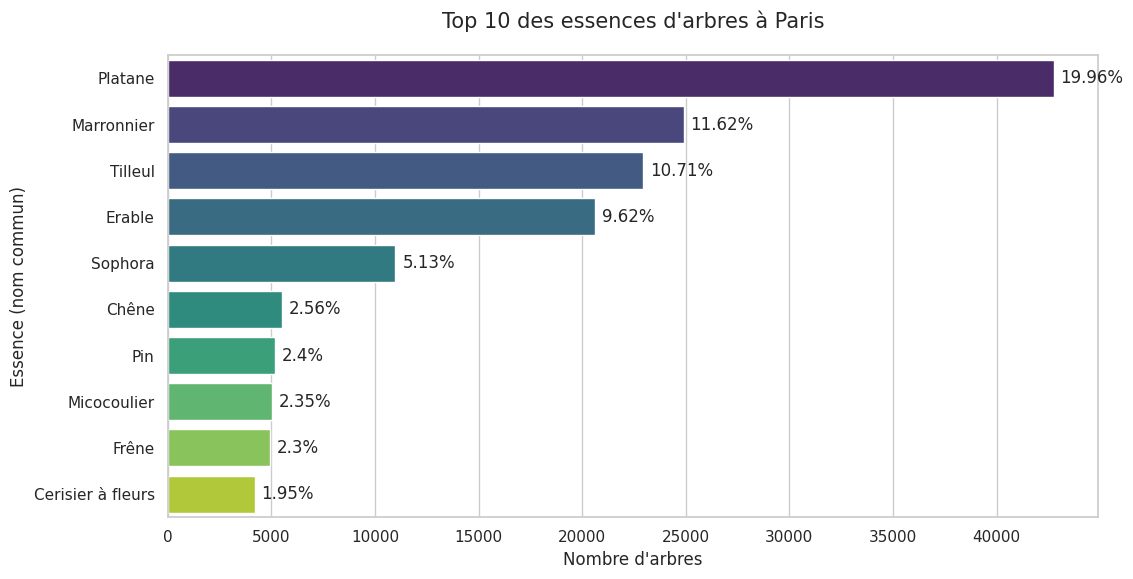

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Récupération des données via ton module
df_top = utils.get_top_species(arbres, column_name = "LIBELLE FRANCAIS")

# 2. Création du graphique
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_top, 
    x='Nombre', 
    y='Espece', 
    palette='viridis'
)

# 3. Cosmétique (pour que ce soit "qualitatif")
plt.title('Top 10 des essences d\'arbres à Paris', fontsize=15, pad=20)
plt.xlabel('Nombre d\'arbres')
plt.ylabel('Essence (nom commun)')

# Ajout des pourcentages au bout des barres
for i, p in enumerate(ax.patches):
    percentage = f"{df_top['Pourcentage'].iloc[i]}%"
    ax.annotate(percentage, (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

Puis nous nous interrogeons sur l'ancienneté des arbres. 

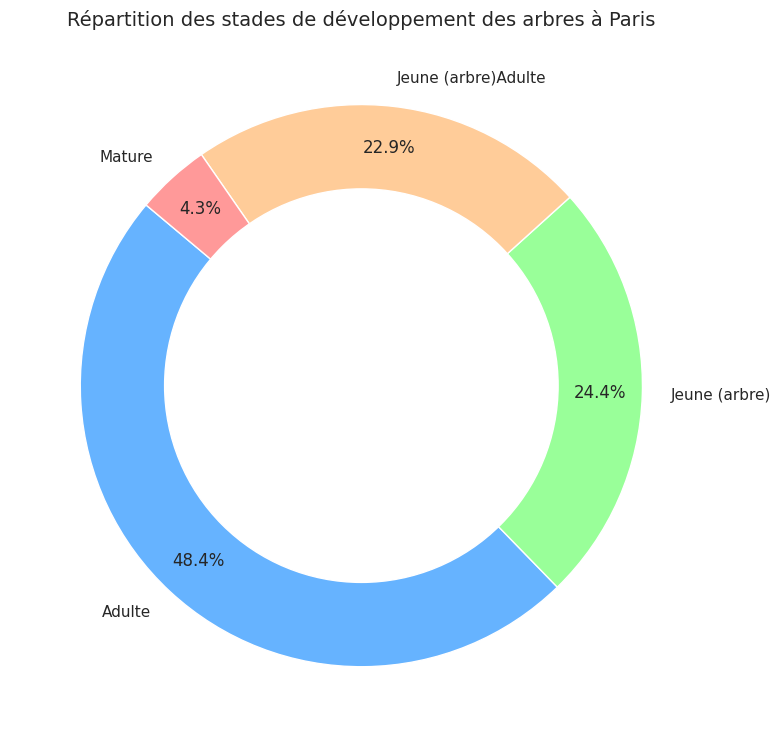

In [11]:
df_stade = utils.get_development_stats(arbres)

# 2. Visualisation (Donut Chart)
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'] # Couleurs douces

plt.pie(
    df_stade['Proportion'], 
    labels=df_stade['Stade'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85
)

# Dessiner un cercle blanc au milieu pour faire un "Donut"
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Répartition des stades de développement des arbres à Paris", fontsize=14)
plt.tight_layout()
plt.show()

On peut ensuite modéliser ces stades moyens de développement par Iris ou par arrondissement de façon intéractvie pour se rendre davatage compte de la typologie parisienne des arbres. 

In [15]:
print("\n--- INFOS GÉNÉRALES ---")

gdf_iris_stats = utils.preparer_geodata_stade(iris, df_arbres, niveau='iris')
gdf_iris_stats[['code_iris', 'nom_iris', 'stade_dominant', 'pct_Jeune', 'pct_Adulte', 'pct_Vieux']].head()

mapping_arrdt = {
    '75101': 'PARIS 1ER ARRDT',
    '75102': 'PARIS 2E ARRDT',
    '75103': 'PARIS 3E ARRDT',
    '75104': 'PARIS 4E ARRDT',
    '75105': 'PARIS 5E ARRDT',
    '75106': 'PARIS 6E ARRDT',
    '75107': 'PARIS 7E ARRDT',
    '75108': 'PARIS 8E ARRDT',
    '75109': 'PARIS 9E ARRDT',
    '75110': 'PARIS 10E ARRDT',
    '75111': 'PARIS 11E ARRDT',
    '75112': 'PARIS 12E ARRDT',
    '75113': 'PARIS 13E ARRDT',
    '75114': 'PARIS 14E ARRDT',
    '75115': 'PARIS 15E ARRDT',
    '75116': 'PARIS 16E ARRDT',
    '75117': 'PARIS 17E ARRDT',
    '75118': 'PARIS 18E ARRDT',
    '75119': 'PARIS 19E ARRDT',
    '75120': 'PARIS 20E ARRDT',
}

iris_avec_arrdt = iris.copy()
iris_avec_arrdt['arrondissement'] = iris_avec_arrdt['code_insee'].map(mapping_arrdt)

# On ne garde que les vrais arrondissements (exclut Bois de Vincennes etc.)
iris_avec_arrdt = iris_avec_arrdt[iris_avec_arrdt['arrondissement'].notna()]

# Dissolve → un polygone par arrondissement
gdf_arrdt = iris_avec_arrdt.dissolve(by='arrondissement').reset_index()[['arrondissement', 'geometry']]

# Stats et carte
gdf_arrdt_stats = utils.preparer_geodata_stade(gdf_arrdt, df_arbres, niveau='arrondissement')

# Vérification
print(gdf_arrdt_stats[['ARRONDISSEMENT', 'stade_dominant', 'total', 'pct_Jeune', 'pct_Adulte', 'pct_Vieux']])

carte = utils.carte_stade_paris(
    gdf_iris_stats=gdf_iris_stats,
    gdf_arrdt_stats=gdf_arrdt_stats,
    titre="Stade dominant des arbres à Paris"
)
carte


--- INFOS GÉNÉRALES ---


KeyError: 'STADE DE DEVELOPPEMENT'

On veut ensuite représenter la desnité de population dans Paris. Selon les IRIS ou les arrondissement et toujours de manière intéractive. On ajoute aussi un figuré ponctuel avec les arbres remarquables de Paris.

In [ ]:
gdf_iris_densite = utils.calculer_densite_par_zone(df_arbres, iris, groupby_col='code_iris')

# Densité par arrondissement (réutilise gdf_arrdt construit précédemment)
gdf_arrdt_densite = utils.calculer_densite_par_zone(df_arbres, gdf_arrdt, groupby_col='ARRONDISSEMENT')

# Arbres remarquables (top 50 hauteur + top 50 circonférence + colonne REMARQUABLE)
gdf_remarquables = utils.extraire_arbres_remarquables(df_arbres, top_n_hauteur=50, top_n_circonf=50)
print(f"{len(gdf_remarquables)} arbres remarquables extraits")
print(gdf_remarquables[['LIBELLE FRANCAIS', 'HAUTEUR (m)', 'CIRCONFERENCE (cm)', 'motif_remarquable']].head())

carte_densite = utils.carte_densite_paris(
    gdf_iris_densite=gdf_iris_densite,
    gdf_arrdt_densite=gdf_arrdt_densite,
    gdf_remarquables=gdf_remarquables,
    titre="Densité d'arbres à Paris"
)
carte_densite


### Clustering 

Nous utilisons maintenant une méthode de clustering pour établir des profils types d'iris en fonction de leur population d'arbres. 

Préaration de la base de données pour le clustering + test du coude pour trouver nombre de cluster idéal 

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

iris_for_clustering = df_arbres.groupby('cleabs').agg({
    'CIRCONFERENCE (cm)': ['mean', 'std'], 
    'HAUTEUR (m)': ['mean', 'max'],        
    'IDBASE': 'count'                  
}).reset_index()

iris_for_clustering.columns = [
    'cleabs', 'circ_moyenne', 'circ_std', 
    'haut_moyenne', 'haut_max', 'nb_arbres'
]

iris_for_clustering = iris_for_clustering.fillna(0)


# 1. Sélection des colonnes numériques uniquement
X = iris_for_clustering.drop(columns=['cleabs'])

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Application du K-Means (testons avec 4 groupes pour commencer)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
iris_for_clustering['cluster'] = kmeans.fit_predict(X_scaled)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled) 
    inertia.append(kmeans.inertia_)

# Tracé
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Distorsion)')
plt.title('Méthode du Coude pour déterminer le k optimal')
plt.grid(True)
plt.show()


D'après le théorème du coude, il semble plus optimal de choisir un k = 4
On peut donc faire notre clustering avec 4 clusters

In [ ]:
custom_palette = {
    0: "#a1d99b",  # Vert tendre
    1: "#41ab5d",  # Vert soutenu
    2: "#e5f5e0",  # Vert très pâle
    3: "#00441b"   # Vert forêt profond
}

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# On trace la hauteur en fonction de la circonférence, colorée par cluster
sns.scatterplot(data=iris_for_clustering, 
                x='circ_moyenne', 
                y='haut_moyenne', 
                hue='cluster', 
                palette=custom_palette, 
                s=100, alpha=0.7)

plt.title('Profil morphologique des arbres par Cluster')
plt.xlabel('Circonférence moyenne (cm)')
plt.ylabel('Hauteur moyenne (m)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

stats_clusters = iris_for_clustering.groupby('cluster').mean(numeric_only=True)

print(stats_clusters)


En affichant les moyennes de hauteurs, circonferences et nombre par cluster, on voit bien que 4 groupes bien distincts se créeent: 

1.	Cluster 3 (Le plus foncé) : Les "Forêts Urbaines". Moyenne de 3038 arbres et une hauteur max record de 30m. C'est le cluster des bois.
2.	Cluster 1 (Vert soutenu) : Les "Quartiers Arborés et Anciens". Ils ont le nombre d'arbres le plus élevé après les bois (179) et la circonférence moyenne la plus forte (97 cm).
3.	Cluster 0 (Vert moyen) : Le "Standard Parisien". Un profil équilibré, environ 134 arbres par IRIS avec une morphologie moyenne.
4.	Cluster 2 (Vert très clair) : Les "Zones Jeunes ou Minérales". Plus petites circonférences (48 cm) et moins d'arbres.

On peut maintenant représenter nos clusters sur une carte: 

In [ ]:
couleurs_vertes = {
    "2": "#e5f5e0",       # Vert très pâle
    "0": "#a1d99b",       # Vert tendre
    "1": "#41ab5d",       # Vert soutenu
    "3": "#00441b",       # Vert forêt profond
    "Sans arbres": "#D3D3D3" # Gris clair pour les zones vides
}

# 2. Conversion sécurisée en texte (on enlève le .astype(int) qui plantait)
map_df['cluster_str'] = map_df['cluster'].astype(str)

fig, ax = plt.subplots(figsize=(15, 12))

# 3. Affichage avec le mapping
map_df.plot(
    color=map_df['cluster_str'].map(couleurs_vertes),
    ax=ax,
    edgecolor='black',
    linewidth=0.1
)

# 4. Légende personnalisée mise à jour
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Zones minérales / Jeunes (C2)', markerfacecolor='#e5f5e0', markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Quartiers moyennement arborés (C0)', markerfacecolor='#a1d99b', markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Patrimoine arboré dense (C1)', markerfacecolor='#41ab5d', markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Bois de Paris (C3)', markerfacecolor='#00441b', markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Aucun arbre recensé', markerfacecolor='#D3D3D3', markersize=15)
]
ax.legend(handles=legend_elements, loc='upper left', title="Typologie végétale")

plt.title("Analyse du patrimoine arboré par IRIS à Paris", fontsize=16)
plt.axis('off')
plt.show()
